In [103]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pypsa

pd.options.future.infer_string = False
pd.options.mode.string_storage = "python"

def hourly_climatology(df):
    df = df[~((df.utc_time.dt.month == 2) & (df.utc_time.dt.day == 29))]
    df["month"] = df["utc_time"].dt.month
    df["day"] = df["utc_time"].dt.day
    df["hour"] = df["utc_time"].dt.hour
    
    result = (
        df.groupby(["month","day","hour"])["cf"]
        .mean()
        .reset_index()
    )
    result["timestamp"] = pd.to_datetime(dict(year=2017, month=result["month"], day=result["day"], hour=result["hour"]))

    result = result.sort_values("timestamp").reset_index(drop=True)

    # Create formatted column
    result["datetime"] = result["timestamp"].dt.strftime("%d/%m %H:%M")

    return result


def load_base_year_data(cf_year):
    """
    If cf_year = None then use 10 year average capacity factor data
    If cf_year is given then show the actual year
    """
    demand = pd.read_csv("../data/denmark_demand.csv", index_col=0)
    if cf_year is None:
        offshore_wind_cf = pd.read_csv("../data/averaged_offshore_wind_capacity_factor_denmark_hourly.csv", index_col=0)
        onshore_wind_cf = pd.read_csv("../data/averaged_onshore_wind_capacity_factor_denmark_hourly.csv", index_col=0)
        pv_cf = pd.read_csv("../data/averaged_pv_capacity_factor_denmark_hourly.csv", index_col=0)
        demand = pd.read_csv("../data/denmark_demand.csv", index_col=0)

        pv = pv_cf.rename(columns={"cf": "pv_cf"})
        onshore = onshore_wind_cf.rename(columns={"cf": "onshore_cf"})
        offshore = offshore_wind_cf.rename(columns={"cf": "offshore_cf"})

        work_df = pd.concat([pv, onshore, offshore, demand], axis=1)
        work_df.index = pd.to_datetime(
            "2015/" + work_df.index.astype(str),
            format="%Y/%d/%m %H:%M"
        )

        work_df.index = work_df.index.strftime("%d/%m/%Y %H:%M")

        work_df = work_df.rename(columns={"demand": "demand_mw"})
        return work_df
    else:

        offshore_wind_cf_df = pd.read_csv("../data/offshore_wind_capacity_factor_raw.csv",delimiter=";")
        onshore_wind_cf_df = pd.read_csv("../data/onshore_wind_capacity_factor_raw.csv", delimiter=";")
        pv_cf_df = pd.read_csv("../data/pv_capacity_factor_raw.csv", delimiter=";")

        # Convert ISO8601 to datetime
        offshore_wind_cf_df["utc_time"] = pd.to_datetime(offshore_wind_cf_df["utc_time"], utc=True, errors="raise")
        onshore_wind_cf_df["utc_time"] = pd.to_datetime(onshore_wind_cf_df["utc_time"], utc=True, errors="raise")
        pv_cf_df["utc_time"] = pd.to_datetime(pv_cf_df["utc_time"], utc=True, errors="raise")

        # Keep only time and Denmark
        df_pv = pv_cf_df[["utc_time", "DNK"]]
        df_onshore_wind = onshore_wind_cf_df[["utc_time", "DNK"]]
        df_offshore_wind = offshore_wind_cf_df[["utc_time", "DNK"]]

        # Filter out the exact year
        df_pv = df_pv[df_pv["utc_time"].dt.year == cf_year]
        df_onshore_wind = df_onshore_wind[df_onshore_wind["utc_time"].dt.year == cf_year]
        df_offshore_wind = df_offshore_wind[df_offshore_wind["utc_time"].dt.year == cf_year]

        # Rename columns
        df_pv = df_pv.rename(columns={"DNK": "cf"})
        df_onshore_wind = df_onshore_wind.rename(columns={"DNK": "cf"})
        df_offshore_wind = df_offshore_wind.rename(columns={"DNK": "cf"})
        
        # Remove year from capacity factor dataframes
        df_pv = hourly_climatology(df_pv)
        df_onshore_wind = hourly_climatology(df_onshore_wind)
        df_offshore_wind = hourly_climatology(df_offshore_wind)

        df_pv = df_pv[["datetime", "cf"]]
        df_onshore_wind = df_onshore_wind[["datetime", "cf"]]
        df_offshore_wind = df_offshore_wind[["datetime", "cf"]]

        # Rename columns
        df_pv = df_pv.rename(columns={"cf": "pv_cf"})
        df_onshore_wind = df_onshore_wind.rename(columns={"cf": "onshore_cf"})
        df_offshore_wind = df_offshore_wind.rename(columns={"cf": "offshore_cf"})

        # Set index
        df_pv = df_pv.set_index("datetime")
        df_onshore_wind = df_onshore_wind.set_index("datetime")
        df_offshore_wind = df_offshore_wind.set_index("datetime")

        # Concat the dataframes
        work_df = pd.concat([df_pv, df_onshore_wind, df_offshore_wind, demand], axis=1)
        work_df.index = pd.to_datetime(
            str(cf_year) + "/" + work_df.index.astype(str),
            format="%Y/%d/%m %H:%M"
        )

        work_df.index = work_df.index.strftime("%d/%m/%Y %H:%M")

        work_df = work_df.rename(columns={"demand": "demand_mw"})
        return work_df
        
# Capacity factor year can be chosen to be different
capacity_factor_year = 2014
work_df = load_base_year_data(capacity_factor_year)
work_df.index = pd.DatetimeIndex(
    pd.to_datetime(work_df.index, format="%d/%m/%Y %H:%M")
)


In [104]:
# Technology lifetimes
onshore_wind_lifetime = 30 # years
offshore_wind_lifetime = 30 # years
pv_lifetime = 35 # years
ccgt_lifetime = 25 # years
ocgt_lifetime = 25 # years
biomass_chp_lifetime = 25 # years

# CAPEX
onshore_wind_capex = 1160000 # EUR/MW
offshore_wind_capex = 2500000 # EUR/MW
pv_capex = 500000 # EUR/MW
ccgt_capex = 900000 # EUR/MW
ocgt_capex = 600000 # EUR/MW
biomass_chp_capex = 5000000 # EUR/MW

# Annualised capital costs
annualised_offshore_wind_capex = offshore_wind_capex / offshore_wind_lifetime # EUR/MW/year
annualised_onshore_wind_capex = onshore_wind_capex / onshore_wind_lifetime # EUR/MW/year
annualised_pv_capex = pv_capex / pv_lifetime # EUR/MW/year
annualised_ccgt_capex = ccgt_capex / ccgt_lifetime # EUR/MW/year
annualised_ocgt_capex = ocgt_capex / ocgt_lifetime # EUR/MW/year
annualised_chp_capex = biomass_chp_capex / biomass_chp_lifetime # EUR/MW/year

# Annual OPEX costs
offshore_wind_opex = 40000 # EUR/MW/year
onshore_wind_opex = 17000 # EUR/MW/year
pv_opex = 10500 # EUR/MW/year
ccgt_opex = 30500 # EUR/MW/year
ocgt_opex = 20000 # EUR/MW/year
chp_opex = 150000 # EUR/MW/year

# Efficiencies of generators
ccgt_efficiency = 0.57
ocgt_efficiency = 0.4
chp_efficiency = 0.25

# Input costs
gas_price = 30 # €/MWh
chp_input_price = 25 # €/MWh

# Setting up marginal generation costs
onshore_wind_marginal_cost = 4 # EUR/MWh
offshore_wind_marginal_cost = 2 # EUR/MWh
pv_marginal_cost = 0 # EUR/MWh
ccgt_marginal_cost = 4.5 + gas_price / ccgt_efficiency # EUR/MWh
ocgt_marginal_cost =  4.5 + gas_price / ocgt_efficiency # EUR/MWh
chp_marginal_cost = 15 + chp_input_price / chp_efficiency # EUR/MWh



# PyPsa setup


In [105]:
n = pypsa.Network()

# Set time snapshots
n.set_snapshots(work_df.index)

# Carriers
n.add(
    "Carrier",
    "OnshoreWind",
    co2_emissions=0,
    nice_name="Onshore wind"
)
n.add(
    "Carrier",
    "OffshoreWind",
    co2_emissions=0,
    nice_name="Offshore wind"
)
n.add(
    "Carrier",
    "PV",
    co2_emissions=0,
    nice_name="PV"
)
n.add(
    "Carrier",
    "AC",
    co2_emissions=0
)
n.add(
    "Carrier",
    "BiomassCHP",
    co2_emissions=0,
    nice_name="Biomass CHP"
)

n.add(
    "Carrier",
    "CCGT",
    co2_emissions=0,
    nice_name="CCGT"
)

n.add(
    "Carrier",
    "OCGT",
    co2_emissions=0,
    nice_name="OCGT"
)

# --- Buses ---
n.add(
    "Bus",
    "DK",
    carrier="AC",
)

# Load
n.add(
    "Load",
    "DKLoad",
    bus="DK",
    p_set=work_df["demand_mw"].to_numpy()
)

# --- Generators ---
n.add(
    "Generator",
    "DKOffshoreWind",
    bus="DK",
    carrier="OffshoreWind",
    p_nom_extendable=True,
    p_max_pu = work_df["offshore_cf"].to_numpy(),
    marginal_cost=float(offshore_wind_marginal_cost),
    capital_cost=float(annualised_offshore_wind_capex),
)

n.add(
    "Generator",
    "DKOnshoreWind",
    bus="DK",
    carrier="OnshoreWind",
    p_nom_extendable=True,
    p_max_pu = work_df["onshore_cf"].to_numpy(),
    marginal_cost=float(onshore_wind_marginal_cost),
    capital_cost=float(annualised_onshore_wind_capex),
)

n.add(
    "Generator",
    "DKPV",
    bus="DK",
    carrier="PV",
    p_nom_extendable=True,
    p_max_pu = work_df["pv_cf"].to_numpy(),
    marginal_cost=float(pv_marginal_cost),
    capital_cost=float(annualised_pv_capex),
)

n.add(
    "Generator",
    "DKBiomassCHP",
    bus="DK",
    carrier="BiomassCHP",
    p_nom_extendable=True,
    marginal_cost=float(chp_marginal_cost),
    capital_cost=float(annualised_chp_capex),
)

n.add(
    "Generator",
    "DKCCGT",
    bus="DK",
    carrier="CCGT",
    p_nom_extendable=True,
    marginal_cost=float(ccgt_marginal_cost),
    capital_cost=float(annualised_ccgt_capex),
)

n.add(
    "Generator",
    "DKOCGT",
    bus="DK",
    carrier="OCGT",
    p_nom_extendable=True,
    marginal_cost=float(ocgt_marginal_cost),
    capital_cost=float(annualised_ocgt_capex),
)

In [106]:
n.generators[["bus", "carrier", "p_nom", "p_max_pu", "capital_cost", "marginal_cost"]].T

name,DKOffshoreWind,DKOnshoreWind,DKPV,DKBiomassCHP,DKCCGT,DKOCGT
bus,DK,DK,DK,DK,DK,DK
carrier,OffshoreWind,OnshoreWind,PV,BiomassCHP,CCGT,OCGT
p_nom,0.0,0.0,0.0,0.0,0.0,0.0
p_max_pu,1.0,1.0,1.0,1.0,1.0,1.0
capital_cost,83333.333333,38666.666667,14285.714286,200000.0,36000.0,24000.0
marginal_cost,2.0,4.0,0.0,115.0,57.131579,79.5


In [107]:
# Solver
n.optimize(solver_name="highs")
#n.statistics()

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 185.57it/s]
INFO:linopy.io: Writing time: 0.2s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 52566 primals, 113886 duals
Objective: 1.28e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


('ok', 'optimal')

## Winter week

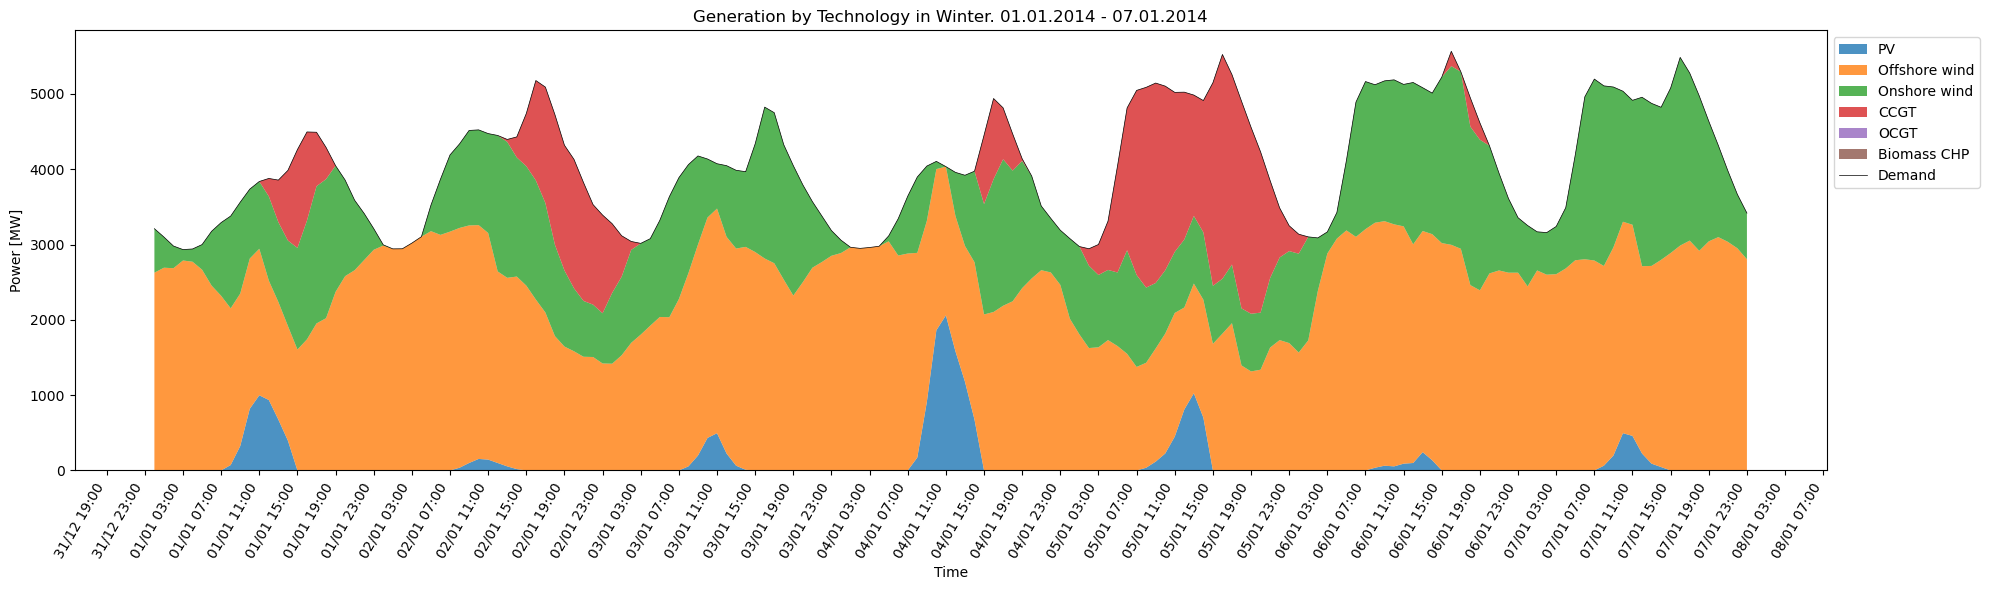

In [108]:
# Date range winter week
if capacity_factor_year is not None:
    start_date = pd.Timestamp(f"{capacity_factor_year}-01-01 00:00:00")
    end_date   = pd.Timestamp(f"{capacity_factor_year}-01-07 23:00:00")
else:
    start_date = pd.Timestamp("2015-01-01 00:00:00")
    end_date   = pd.Timestamp("2015-01-07 23:00:00")

# --- Dispatch ---
dispatch = n.generators_t.p.copy()

carrier_series = n.generators.carrier
nice_name_map = n.carriers.nice_name.to_dict()

dispatch_nice = dispatch.rename(
    columns=lambda g: nice_name_map.get(carrier_series[g], carrier_series[g])
)

dispatch_nice = dispatch_nice.T.groupby(level=0).sum().T

# Marginal cost per technology
cost_df = n.generators[["carrier", "marginal_cost"]].copy()
cost_df["nice_name"] = cost_df["carrier"].map(n.carriers.nice_name)

# If multiple generators per tech → take mean (or min)
cost_by_tech = cost_df.groupby("nice_name")["marginal_cost"].mean()

# Sort technologies (cheapest first)
tech_order = cost_by_tech.sort_values().index.tolist()

# Reorder columns
dispatch_nice = dispatch_nice[tech_order]

# --- Slice time ---
dispatch_plot = dispatch_nice.loc[start_date:end_date]
demand_plot = work_df.loc[start_date:end_date, "demand_mw"]

# Ensure datetime index
dispatch_plot.index = pd.to_datetime(dispatch_plot.index)
demand_plot.index = pd.to_datetime(demand_plot.index)

# --- Plot ---
fig, ax = plt.subplots(figsize=(20, 6))

x = dispatch_plot.index
y = [dispatch_plot[col].to_numpy() for col in dispatch_plot.columns]

ax.stackplot(x, y, labels=dispatch_plot.columns, alpha=0.8)

ax.plot(
    demand_plot.index,
    demand_plot.to_numpy(),
    linewidth=0.5,
    color="black",
    label="Demand"
)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M"))
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")

ax.set_ylabel("Power [MW]")
ax.set_xlabel("Time")

if capacity_factor_year is not None:
    ax.set_title(
    f"Generation by Technology in Winter. "
    f"{start_date.strftime('%d.%m.%Y')} - {end_date.strftime('%d.%m.%Y')}"
)
else:
    ax.set_title("Generation by Technology in Winter. Capacity Factors 10 year average 2007 - 2017.")

ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

## Summer week

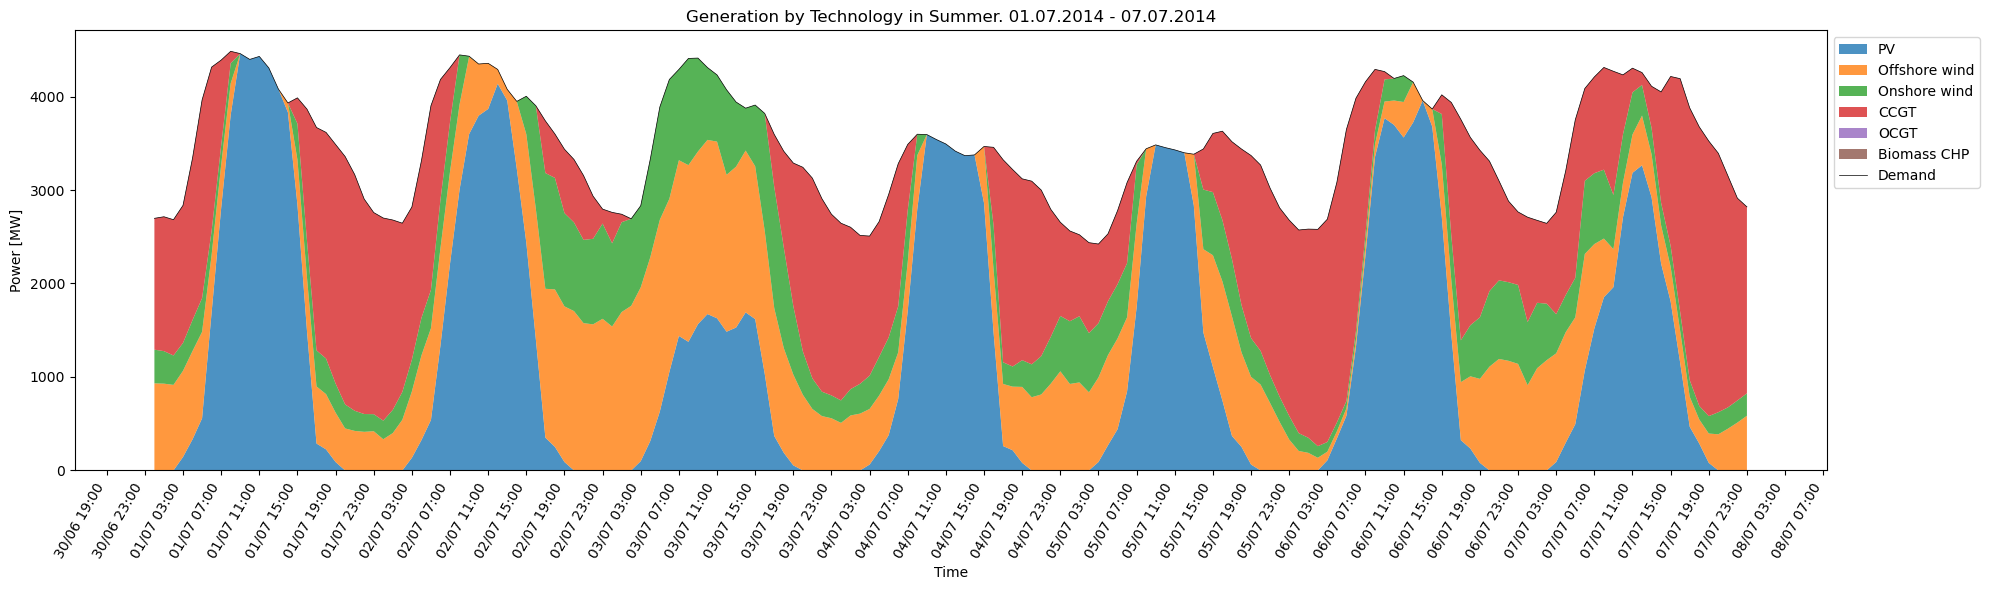

In [109]:
# Date range summer week
if capacity_factor_year is not None:
    start_date = pd.Timestamp(f"{capacity_factor_year}-07-01 00:00:00")
    end_date   = pd.Timestamp(f"{capacity_factor_year}-07-07 23:00:00")
else:
    start_date = pd.Timestamp("2015-07-01 00:00:00")
    end_date   = pd.Timestamp("2015-07-07 23:00:00")

# --- Dispatch ---
dispatch = n.generators_t.p.copy()

carrier_series = n.generators.carrier
nice_name_map = n.carriers.nice_name.to_dict()

dispatch_nice = dispatch.rename(
    columns=lambda g: nice_name_map.get(carrier_series[g], carrier_series[g])
)

dispatch_nice = dispatch_nice.T.groupby(level=0).sum().T

# Marginal cost per technology
cost_df = n.generators[["carrier", "marginal_cost"]].copy()
cost_df["nice_name"] = cost_df["carrier"].map(n.carriers.nice_name)

# If multiple generators per tech → take mean (or min)
cost_by_tech = cost_df.groupby("nice_name")["marginal_cost"].mean()

# Sort technologies (cheapest first)
tech_order = cost_by_tech.sort_values().index.tolist()

# Reorder columns
dispatch_nice = dispatch_nice[tech_order]

# --- Slice time ---
dispatch_plot = dispatch_nice.loc[start_date:end_date]
demand_plot = work_df.loc[start_date:end_date, "demand_mw"]

# Ensure datetime index
dispatch_plot.index = pd.to_datetime(dispatch_plot.index)
demand_plot.index = pd.to_datetime(demand_plot.index)

# --- Plot ---
fig, ax = plt.subplots(figsize=(20, 6))

x = dispatch_plot.index
y = [dispatch_plot[col].to_numpy() for col in dispatch_plot.columns]

ax.stackplot(x, y, labels=dispatch_plot.columns, alpha=0.8)

ax.plot(
    demand_plot.index,
    demand_plot.to_numpy(),
    linewidth=0.5,
    color="black",
    label="Demand"
)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M"))
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")

ax.set_ylabel("Power [MW]")
ax.set_xlabel("Time")

if capacity_factor_year is not None:
    ax.set_title(
    f"Generation by Technology in Summer. "
    f"{start_date.strftime('%d.%m.%Y')} - {end_date.strftime('%d.%m.%Y')}"
)
else:
    ax.set_title("Generation by Technology in Summer. Capacity Factors 10 year average 2007 - 2017.")

ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [110]:
capacity = n.generators[["carrier", "p_nom_opt"]].copy()

# Map to nice names
capacity["Technology"] = capacity["carrier"].map(n.carriers.nice_name)

# Aggregate by technology
capacity_table = (
    capacity.groupby("Technology")["p_nom_opt"]
    .sum()
    .sort_values(ascending=False)
    .round(1)
)

if capacity_factor_year is not None:
    print(f"Year used for simulation: {capacity_factor_year}")
else:
    print("10 year average (2007 - 2017) was used for capacity factors")
print(capacity_table)

Year used for simulation: 2014
Technology
PV               8993.3
Onshore wind     4141.4
Offshore wind    3303.8
CCGT             3048.1
OCGT             2118.5
Biomass CHP         0.0
Name: p_nom_opt, dtype: float64


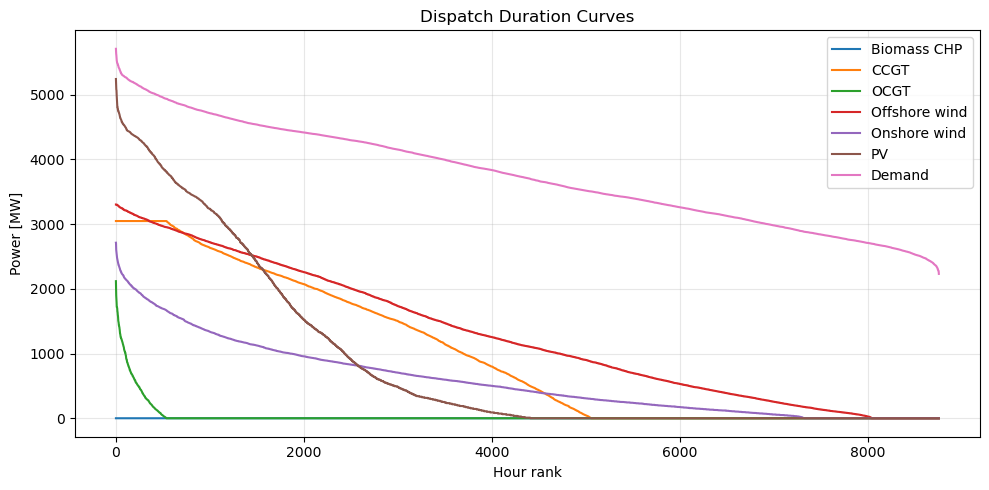

In [111]:
dispatch = n.generators_t.p.copy()

carrier_series = n.generators.carrier
nice_name_map = n.carriers.nice_name.to_dict()

dispatch_nice = dispatch.rename(
    columns=lambda g: nice_name_map.get(carrier_series[g], carrier_series[g])
)

dispatch_nice = dispatch_nice.T.groupby(level=0).sum().T

dispatch_nice["Demand"] = work_df["demand_mw"]

duration_df = pd.DataFrame({
    col: dispatch_nice[col].sort_values(ascending=False).values
    for col in dispatch_nice.columns
})

fig, ax = plt.subplots(figsize=(10, 5))

duration_df.plot(ax=ax)

ax.set_title("Dispatch Duration Curves")
ax.set_xlabel("Hour rank")
ax.set_ylabel("Power [MW]")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# PART B

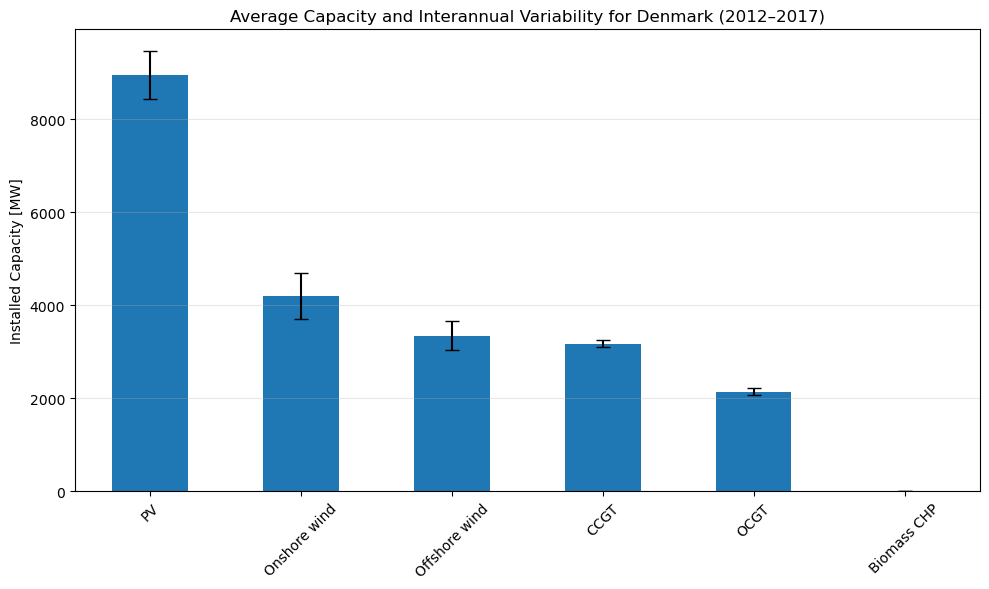

In [112]:
# Results from simulation

capacity_by_year = pd.DataFrame({
    2012: {
        "PV": 8509.3,
        "Onshore wind": 4628.5,
        "Offshore wind": 3184.3,
        "CCGT": 3139.2,
        "OCGT": 1998.1,
        "Biomass CHP": 0.0
    },
    2013: {
        "PV": 9343.4,
        "Onshore wind": 4829.2,
        "Offshore wind": 2838.5,
        "CCGT": 3294.7,
        "OCGT": 2192.7,
        "Biomass CHP": 0.0
    },
    2014: {
        "PV": 8993.3,
        "Onshore wind": 4141.4,
        "Offshore wind": 3303.8,
        "CCGT": 3048.1,
        "OCGT": 2118.5,
        "Biomass CHP": 0.0
    },
    2015: {
        "PV": 8434.8,
        "Onshore wind": 3966.9,
        "Offshore wind": 3385.3,
        "CCGT": 3189.5,
        "OCGT": 2211.1,
        "Biomass CHP": 0.0
    },
    2016: {
        "PV": 9729.0,
        "Onshore wind": 3448.4,
        "Offshore wind": 3703.2,
        "CCGT": 3208.9,
        "OCGT": 2110.4,
        "Biomass CHP": 0.0
    },
    2017: {
        "PV": 8686.0,
        "Onshore wind": 4141.6,
        "Offshore wind": 3609.8,
        "CCGT": 3161.1,
        "OCGT": 2197.2,
        "Biomass CHP": 0.0
    }
}).T

mean_capacity = capacity_by_year.mean()
std_capacity = capacity_by_year.std()

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

mean_capacity.plot.bar(
    yerr=std_capacity,
    ax=ax,
    capsize=5
)

ax.set_ylabel("Installed Capacity [MW]")
ax.set_title("Average Capacity and Interannual Variability for Denmark (2012–2017)")
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# PART C

In [113]:
# Add battery variables
battery_lifetime = 17

# Battery CAPEX
battery_capex = 450000 # EUR/MW

# Annualised capital costs
annualised_battery_inverter_capex = battery_capex / battery_lifetime # EUR/MW/year
annualised_battery_energy_capex = 0.5 # EUR/MWh/year

# Annual OPEX costs
battery_opex = 10000 # EUR/MW/year

# Battery energy-to-power ratio
battery_hours = 2

# Efficiencies
battery_inverter_efficiency = 0.96

In [114]:
n = pypsa.Network()

# Set time snapshots
n.set_snapshots(work_df.index)

# Carriers
n.add(
    "Carrier",
    "OnshoreWind",
    co2_emissions=0,
    nice_name="Onshore wind"
)
n.add(
    "Carrier",
    "OffshoreWind",
    co2_emissions=0,
    nice_name="Offshore wind"
)
n.add(
    "Carrier",
    "PV",
    co2_emissions=0,
    nice_name="PV"
)
n.add(
    "Carrier",
    "AC",
    co2_emissions=0
)
n.add(
    "Carrier",
    "BiomassCHP",
    co2_emissions=0,
    nice_name="Biomass CHP"
)
n.add(
    "Carrier",
    "CCGT",
    co2_emissions=0,
    nice_name="CCGT"
)

n.add(
    "Carrier",
    "OCGT",
    co2_emissions=0,
    nice_name="OCGT"
)

n.add(
    "Carrier",
    "BESS",
    co2_emissions=0,
    nice_name="BESS"
)

n.add(
    "Carrier",
    "BESS4h",
    co2_emissions=0,
    nice_name="BESS 4H"
)

# --- Buses ---
n.add(
    "Bus",
    "DK",
    carrier="AC",
)

# Load
n.add(
    "Load",
    "DKLoad",
    bus="DK",
    p_set=work_df["demand_mw"].to_numpy()
)

# --- Generators ---
n.add(
    "Generator",
    "DKOffshoreWind",
    bus="DK",
    carrier="OffshoreWind",
    p_nom_extendable=True,
    p_max_pu = work_df["offshore_cf"].to_numpy(),
    marginal_cost=float(offshore_wind_marginal_cost),
    capital_cost=float(annualised_offshore_wind_capex),
)

n.add(
    "Generator",
    "DKOnshoreWind",
    bus="DK",
    carrier="OnshoreWind",
    p_nom_extendable=True,
    p_max_pu = work_df["onshore_cf"].to_numpy(),
    marginal_cost=float(onshore_wind_marginal_cost),
    capital_cost=float(annualised_onshore_wind_capex),
)

n.add(
    "Generator",
    "DKPV",
    bus="DK",
    carrier="PV",
    p_nom_extendable=True,
    p_max_pu = work_df["pv_cf"].to_numpy(),
    marginal_cost=float(pv_marginal_cost),
    capital_cost=float(annualised_pv_capex),
)

n.add(
    "Generator",
    "DKBiomassCHP",
    bus="DK",
    carrier="BiomassCHP",
    p_nom_extendable=True,
    marginal_cost=float(chp_marginal_cost),
    capital_cost=float(annualised_chp_capex),
)

n.add(
    "Generator",
    "DKCCGT",
    bus="DK",
    carrier="CCGT",
    p_nom_extendable=True,
    marginal_cost=float(ccgt_marginal_cost),
    capital_cost=float(annualised_ccgt_capex),
)

n.add(
    "Generator",
    "DKOCGT",
    bus="DK",
    carrier="OCGT",
    p_nom_extendable=True,
    marginal_cost=float(ocgt_marginal_cost),
    capital_cost=float(annualised_ocgt_capex),
)

# --- Storage Units ---
battery_total_annualised_capex = annualised_battery_inverter_capex + battery_opex

n.add(
    "StorageUnit",
    "DKBESS",
    bus="DK",
    carrier="BESS",
    p_nom_extendable=True,
    max_hours=battery_hours,
    efficiency_store=battery_inverter_efficiency,
    efficiency_dispatch=battery_inverter_efficiency,
    capital_cost=battery_total_annualised_capex,
    marginal_cost=0.0,
    cyclic_state_of_charge=True
)

In [115]:
n.generators[["bus", "carrier", "p_nom", "p_max_pu", "capital_cost", "marginal_cost"]].T

name,DKOffshoreWind,DKOnshoreWind,DKPV,DKBiomassCHP,DKCCGT,DKOCGT
bus,DK,DK,DK,DK,DK,DK
carrier,OffshoreWind,OnshoreWind,PV,BiomassCHP,CCGT,OCGT
p_nom,0.0,0.0,0.0,0.0,0.0,0.0
p_max_pu,1.0,1.0,1.0,1.0,1.0,1.0
capital_cost,83333.333333,38666.666667,14285.714286,200000.0,36000.0,24000.0
marginal_cost,2.0,4.0,0.0,115.0,57.131579,79.5


In [116]:
n.storage_units[["bus", "carrier", "p_nom", "p_max_pu", "capital_cost", "marginal_cost"]].T

name,DKBESS
bus,DK
carrier,BESS
p_nom,0.0
p_max_pu,1.0
capital_cost,36470.588235
marginal_cost,0.0


In [117]:
# Solver
n.optimize(solver_name="highs")

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 244.33it/s]
INFO:linopy.io: Writing time: 0.37s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 78847 primals, 175207 duals
Objective: 1.27e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

## Winter week

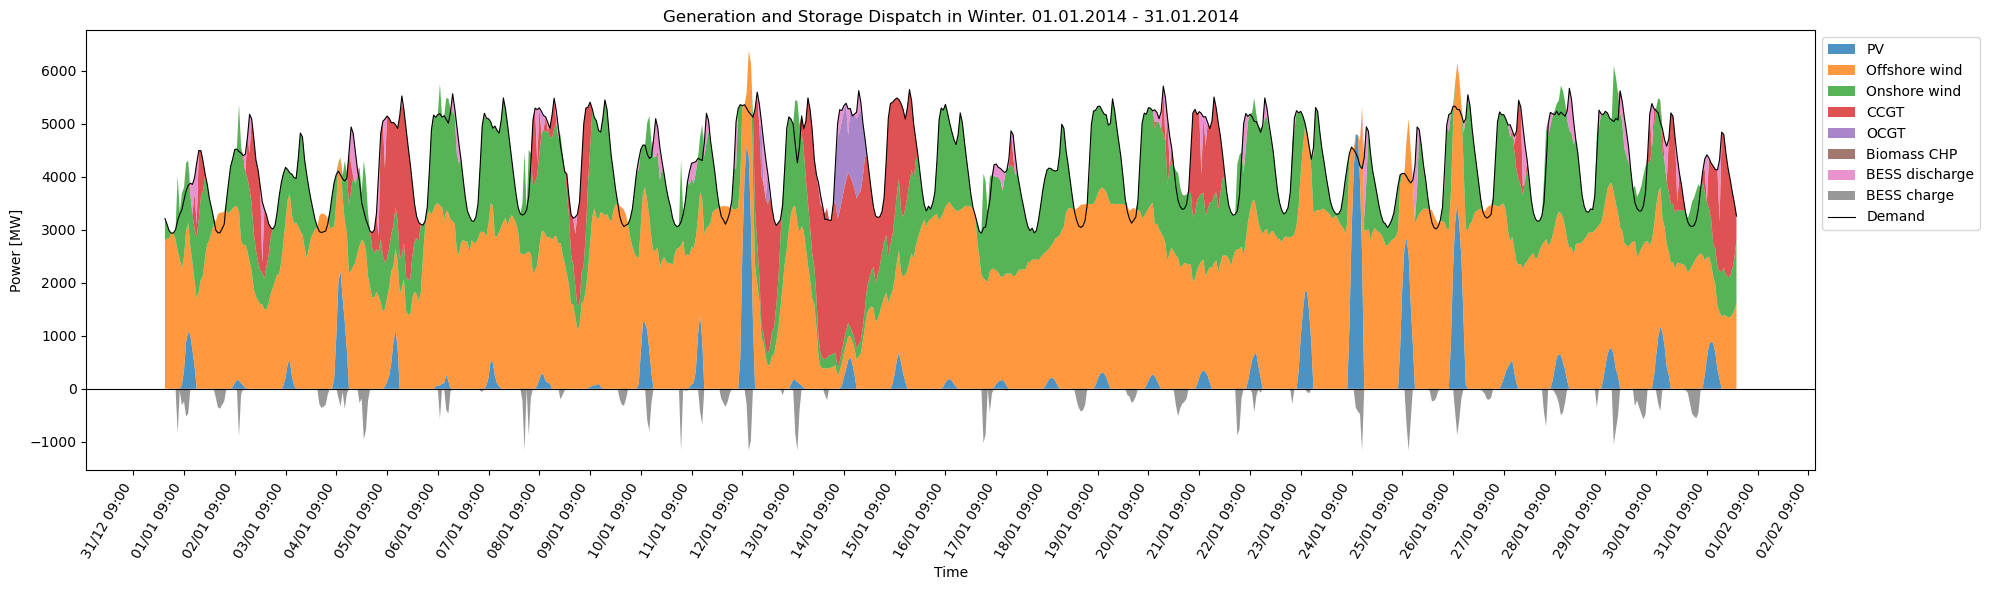

In [118]:
import numpy as np
# Date range winter week
if capacity_factor_year is not None:
    start_date = pd.Timestamp(f"{capacity_factor_year}-01-01 00:00:00")
    end_date   = pd.Timestamp(f"{capacity_factor_year}-01-31 23:00:00")
else:
    start_date = pd.Timestamp("2015-01-01 00:00:00")
    end_date   = pd.Timestamp("2015-01-31 23:00:00")

# ----------------------------
# GENERATORS
# ----------------------------
dispatch = n.generators_t.p.copy()

carrier_series = n.generators.carrier
nice_name_map = n.carriers.nice_name.to_dict()

dispatch_nice = dispatch.rename(
    columns=lambda g: nice_name_map.get(carrier_series[g], carrier_series[g])
)
dispatch_nice = dispatch_nice.T.groupby(level=0).sum().T

# Marginal cost ordering for generators
cost_df = n.generators[["carrier", "marginal_cost"]].copy()
cost_df["nice_name"] = cost_df["carrier"].map(n.carriers.nice_name)
cost_by_tech = cost_df.groupby("nice_name")["marginal_cost"].mean()
tech_order = cost_by_tech.sort_values().index.tolist()

dispatch_nice = dispatch_nice[tech_order]

# ----------------------------
# STORAGE UNITS
# ----------------------------
# Positive = discharge, negative = charge
storage_p = n.storage_units_t.p.copy()

if not storage_p.empty:
    storage_nice_map = n.storage_units.carrier.map(n.carriers.nice_name).to_dict()

    storage_nice = storage_p.rename(
        columns=lambda s: storage_nice_map.get(s, s)
    )
    storage_nice = storage_nice.T.groupby(level=0).sum().T

    storage_discharge = storage_nice.clip(lower=0)
    storage_charge = storage_nice.clip(upper=0)
else:
    storage_discharge = pd.DataFrame(index=dispatch_nice.index)
    storage_charge = pd.DataFrame(index=dispatch_nice.index)

# ----------------------------
# SLICE TIME
# ----------------------------
dispatch_plot = dispatch_nice.loc[start_date:end_date].copy()
demand_plot = work_df.loc[start_date:end_date, "demand_mw"].copy()
storage_discharge_plot = storage_discharge.loc[start_date:end_date].copy()
storage_charge_plot = storage_charge.loc[start_date:end_date].copy()

dispatch_plot.index = pd.to_datetime(dispatch_plot.index)
demand_plot.index = pd.to_datetime(demand_plot.index)
storage_discharge_plot.index = pd.to_datetime(storage_discharge_plot.index)
storage_charge_plot.index = pd.to_datetime(storage_charge_plot.index)

# ----------------------------
# PLOT
# ----------------------------
fig, ax = plt.subplots(figsize=(20, 6))
x = dispatch_plot.index

# Positive stack: generators first
pos_cum = np.zeros(len(x))
for col in dispatch_plot.columns:
    y = dispatch_plot[col].to_numpy()
    ax.fill_between(x, pos_cum, pos_cum + y, alpha=0.8, label=col)
    pos_cum = pos_cum + y

# Positive stack: storage discharge on top
for col in storage_discharge_plot.columns:
    y = storage_discharge_plot[col].to_numpy()
    if np.any(y != 0):
        ax.fill_between(x, pos_cum, pos_cum + y, alpha=0.8, label=f"{col} discharge")
        pos_cum = pos_cum + y

# Negative stack: storage charging below zero
neg_cum = np.zeros(len(x))
for col in storage_charge_plot.columns:
    y = storage_charge_plot[col].to_numpy()  # negative or zero
    if np.any(y != 0):
        ax.fill_between(x, neg_cum, neg_cum + y, alpha=0.8, label=f"{col} charge")
        neg_cum = neg_cum + y

# Demand line
ax.plot(
    demand_plot.index,
    demand_plot.to_numpy(),
    linewidth=0.8,
    color="black",
    label="Demand"
)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M"))
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")

ax.axhline(0, color="black", linewidth=0.8)

ax.set_ylabel("Power [MW]")
ax.set_xlabel("Time")

if capacity_factor_year is not None:
    ax.set_title(
        f"Generation and Storage Dispatch in Winter. "
        f"{start_date.strftime('%d.%m.%Y')} - {end_date.strftime('%d.%m.%Y')}"
    )
else:
    ax.set_title("Generation and Storage Dispatch in Winter. Capacity Factors 10 year average 2007 - 2017.")

ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

## Summer week

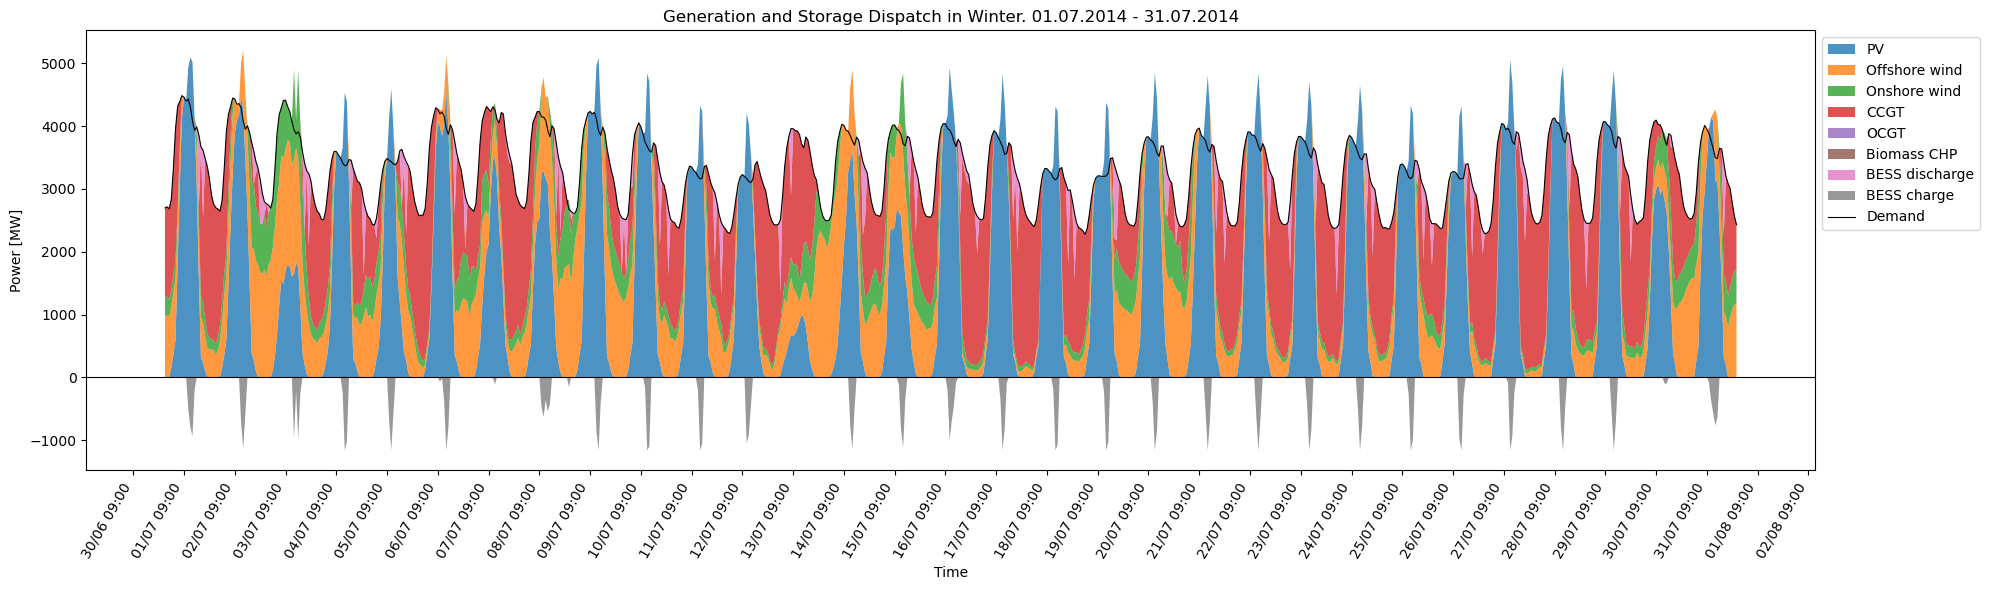

In [ ]:
import numpy as np
# Date range week
if capacity_factor_year is not None:
    start_date = pd.Timestamp(f"{capacity_factor_year}-07-01 00:00:00")
    end_date   = pd.Timestamp(f"{capacity_factor_year}-07-31 23:00:00")
else:
    start_date = pd.Timestamp("2015-07-01 00:00:00")
    end_date   = pd.Timestamp("2015-07-31 23:00:00")

# ----------------------------
# GENERATORS
# ----------------------------
dispatch = n.generators_t.p.copy()

carrier_series = n.generators.carrier
nice_name_map = n.carriers.nice_name.to_dict()

dispatch_nice = dispatch.rename(
    columns=lambda g: nice_name_map.get(carrier_series[g], carrier_series[g])
)
dispatch_nice = dispatch_nice.T.groupby(level=0).sum().T

# Marginal cost ordering for generators
cost_df = n.generators[["carrier", "marginal_cost"]].copy()
cost_df["nice_name"] = cost_df["carrier"].map(n.carriers.nice_name)
cost_by_tech = cost_df.groupby("nice_name")["marginal_cost"].mean()
tech_order = cost_by_tech.sort_values().index.tolist()

dispatch_nice = dispatch_nice[tech_order]

# ----------------------------
# STORAGE UNITS
# ----------------------------
# Positive = discharge, negative = charge
storage_p = n.storage_units_t.p.copy()

if not storage_p.empty:
    storage_nice_map = n.storage_units.carrier.map(n.carriers.nice_name).to_dict()

    storage_nice = storage_p.rename(
        columns=lambda s: storage_nice_map.get(s, s)
    )
    storage_nice = storage_nice.T.groupby(level=0).sum().T

    storage_discharge = storage_nice.clip(lower=0)
    storage_charge = storage_nice.clip(upper=0)
else:
    storage_discharge = pd.DataFrame(index=dispatch_nice.index)
    storage_charge = pd.DataFrame(index=dispatch_nice.index)

# ----------------------------
# SLICE TIME
# ----------------------------
dispatch_plot = dispatch_nice.loc[start_date:end_date].copy()
demand_plot = work_df.loc[start_date:end_date, "demand_mw"].copy()
storage_discharge_plot = storage_discharge.loc[start_date:end_date].copy()
storage_charge_plot = storage_charge.loc[start_date:end_date].copy()

dispatch_plot.index = pd.to_datetime(dispatch_plot.index)
demand_plot.index = pd.to_datetime(demand_plot.index)
storage_discharge_plot.index = pd.to_datetime(storage_discharge_plot.index)
storage_charge_plot.index = pd.to_datetime(storage_charge_plot.index)

# ----------------------------
# PLOT
# ----------------------------
fig, ax = plt.subplots(figsize=(20, 6))
x = dispatch_plot.index

# Positive stack: generators first
pos_cum = np.zeros(len(x))
for col in dispatch_plot.columns:
    y = dispatch_plot[col].to_numpy()
    ax.fill_between(x, pos_cum, pos_cum + y, alpha=0.8, label=col)
    pos_cum = pos_cum + y

# Positive stack: storage discharge on top
for col in storage_discharge_plot.columns:
    y = storage_discharge_plot[col].to_numpy()
    if np.any(y != 0):
        ax.fill_between(x, pos_cum, pos_cum + y, alpha=0.8, label=f"{col} discharge")
        pos_cum = pos_cum + y

# Negative stack: storage charging below zero
neg_cum = np.zeros(len(x))
for col in storage_charge_plot.columns:
    y = storage_charge_plot[col].to_numpy()  # negative or zero
    if np.any(y != 0):
        ax.fill_between(x, neg_cum, neg_cum + y, alpha=0.8, label=f"{col} charge")
        neg_cum = neg_cum + y

# Demand line
ax.plot(
    demand_plot.index,
    demand_plot.to_numpy(),
    linewidth=0.8,
    color="black",
    label="Demand"
)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M"))
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")

ax.axhline(0, color="black", linewidth=0.8)

ax.set_ylabel("Power [MW]")
ax.set_xlabel("Time")

if capacity_factor_year is not None:
    ax.set_title(
        f"Generation and Storage Dispatch in Summer. "
        f"{start_date.strftime('%d.%m.%Y')} - {end_date.strftime('%d.%m.%Y')}"
    )
else:
    ax.set_title("Generation and Storage Dispatch in Summer. Capacity Factors 10 year average 2007 - 2017.")

ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [120]:
# Generators
gen_capacity = n.generators[["carrier", "p_nom_opt"]].copy()
gen_capacity["Technology"] = gen_capacity["carrier"].map(n.carriers.nice_name)

# Storage units
su_capacity = n.storage_units[["carrier", "p_nom_opt"]].copy()
su_capacity["Technology"] = su_capacity["carrier"].map(n.carriers.nice_name)

# Combine
capacity = pd.concat([
    gen_capacity[["Technology", "p_nom_opt"]],
    su_capacity[["Technology", "p_nom_opt"]]
], axis=0)

# Aggregate by technology
capacity_table = (
    capacity.groupby("Technology")["p_nom_opt"]
    .sum()
    .sort_values(ascending=False)
    .round(1)
)

if capacity_factor_year is not None:
    print(f"Year used for simulation: {capacity_factor_year}")
else:
    print("10 year average (2007 - 2017) was used for capacity factors")

print(capacity_table)

Year used for simulation: 2014
Technology
PV               9701.9
Onshore wind     3583.1
Offshore wind    3492.1
CCGT             2831.7
OCGT             1505.5
BESS             1163.6
Biomass CHP         0.0
Name: p_nom_opt, dtype: float64
